# 7. Comparación de resultados y reflexión crítica

Este capítulo corresponde a la sección 9.10.4.8 y al entregable 9.10.5. Reúne en tablas y gráficos comparativos:

* las métricas de los seis modelos en ambos entornos;
* los tiempos de cómputo;
* los resultados de las tres pruebas estadísticas.

Cierra con la reflexión crítica que pide el enunciado. Todo se lee de los resultados que guardaron los capítulos 2 a 6. La única excepción es el experimento de escalabilidad de la sección 7.5, que mide tiempos de ajuste con volúmenes crecientes.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import RocCurveDisplay, roc_auc_score

import lc_utils as U

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

res = {"scikit-learn": json.loads(U.RESULTS_SK.read_text()), "PySpark": json.loads(U.RESULTS_SPARK.read_text())}
scores = {"scikit-learn": pd.read_parquet(U.SCORES_SK), "PySpark": pd.read_parquet(U.SCORES_SPARK)}
stats_res = json.loads((U.DATA_DIR / "stats_results.json").read_text(encoding="utf-8"))
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
ENVS = ["scikit-learn", "PySpark"]

## 7.1 Tabla comparativa de métricas

Las métricas que dependen de un umbral (accuracy, precision, recall y F1) usan el umbral de cada modelo fijado en entrenamiento. El AUC de la tabla es el exacto, calculado con las puntuaciones del conjunto de prueba común.

In [2]:
rows = []
for env in ENVS:
    for m in U.MODELS:
        r = res[env][m]
        rows.append({"entorno": env, "modelo": m,
                     **{f"train {k}": r["train"][k] for k in ["roc_auc", "f1"]},
                     **{f"test {k}": r["test"][k] for k in ["accuracy", "precision", "recall", "f1", "pr_auc"]},
                     "test roc_auc": roc_auc_score(scores[env][U.TARGET], scores[env][m]),
                     "AUC CV": r["cv_auc"], "mejores hiperparámetros": str(r["best_params"] or "(por defecto)")})
table = pd.DataFrame(rows).set_index(["entorno", "modelo"])
table["brecha AUC train−test"] = table["train roc_auc"] - table["test roc_auc"]
num_cols = [c for c in table.columns if c != "mejores hiperparámetros"]
(table.style.format({c: "{:.4f}" for c in num_cols})
      .highlight_max(subset=["test roc_auc", "test pr_auc", "test f1"], props="font-weight: bold; background-color: #d9ead3"))

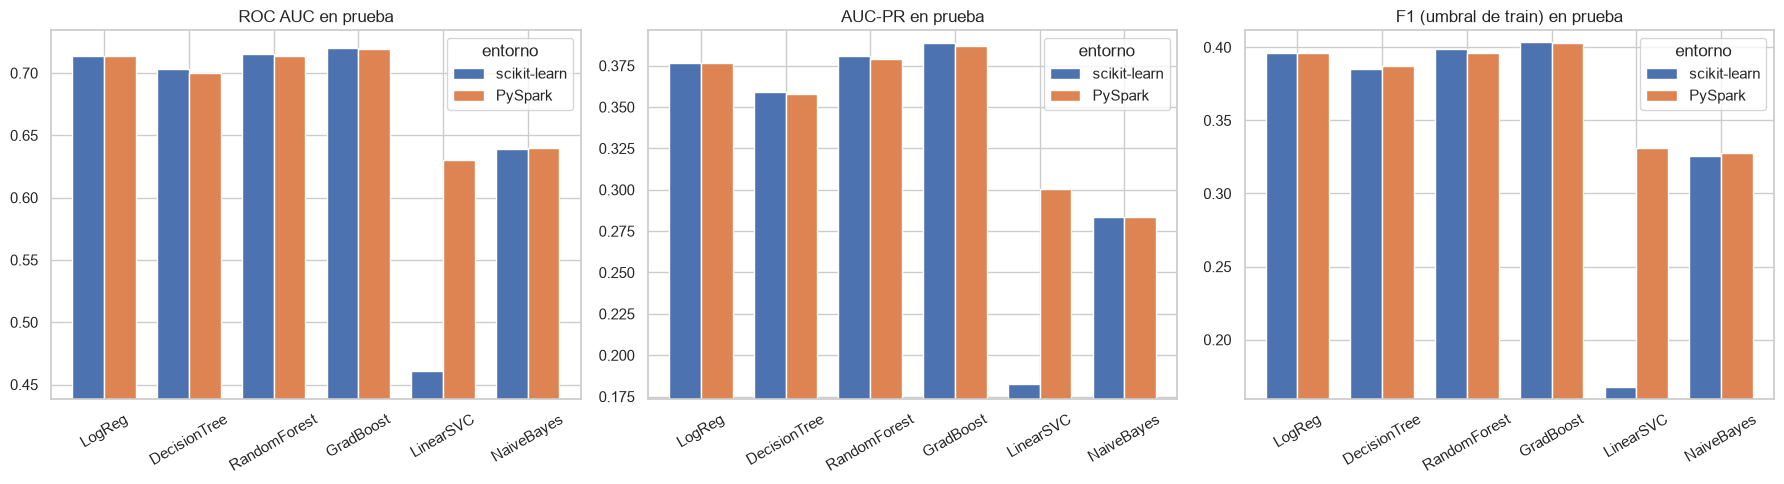

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, lab in zip(axes, ["test roc_auc", "test pr_auc", "test f1"], ["ROC AUC", "AUC-PR", "F1 (umbral de train)"]):
    d = table[metric].unstack(0)[ENVS].loc[U.MODELS]
    d.plot.bar(ax=ax, color=["#4C72B0", "#DD8452"], width=0.75)
    ax.set_title(f"{lab} en prueba")
    ax.set_ylim(d.min().min() * 0.95, d.max().max() * 1.02)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 7.2 Curvas ROC

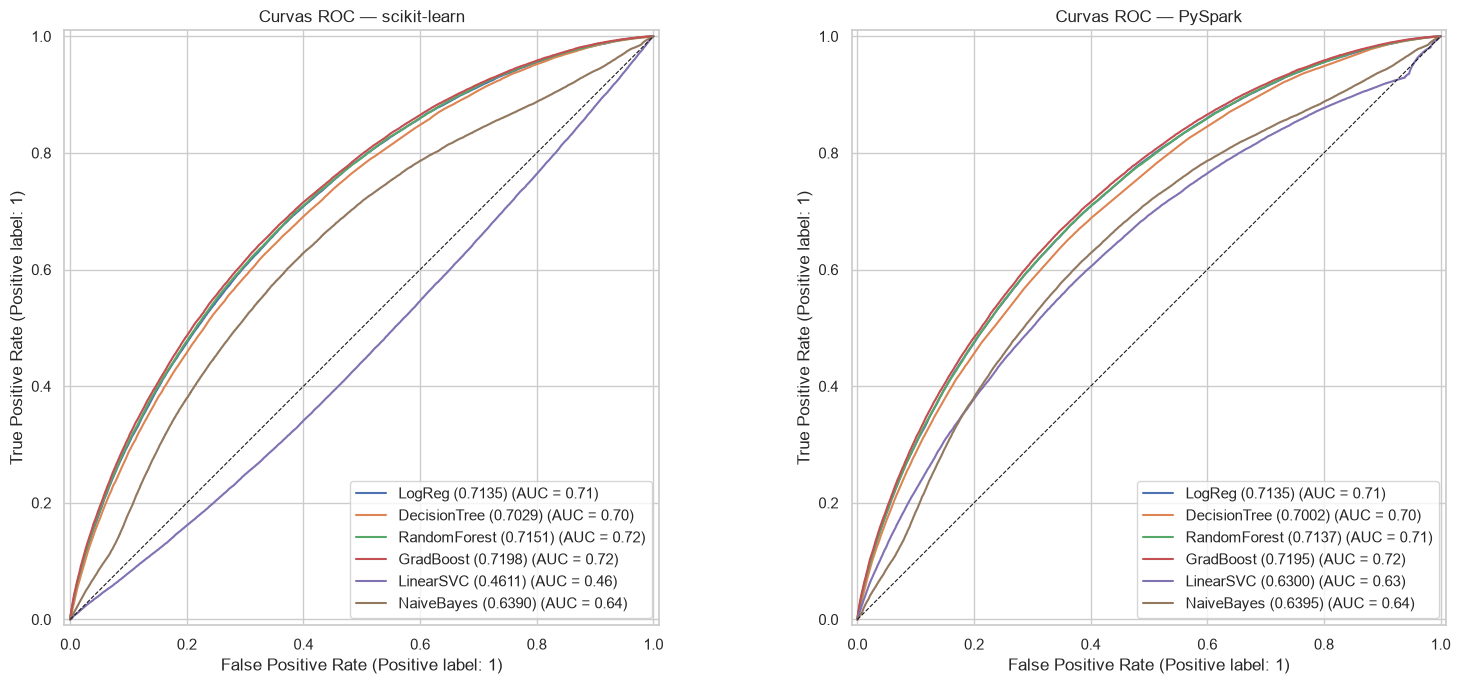

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, env in zip(axes, ENVS):
    s = scores[env]
    for m in U.MODELS:
        RocCurveDisplay.from_predictions(s[U.TARGET], s[m], ax=ax, name=f"{m} ({roc_auc_score(s[U.TARGET], s[m]):.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_title(f"Curvas ROC — {env}")
plt.tight_layout()
plt.show()

## 7.3 Tiempo de cómputo

Los tiempos corresponden al hardware declarado en el capítulo 2. En cada entorno se reportan tres componentes:

* **preprocesamiento:** desde el CSV hasta las matrices o DataFrames listos, incluida la lectura;
* **entrenamiento:** búsqueda de hiperparámetros con validación cruzada de 3 pliegues más el reajuste final;
* **predicción** sobre el conjunto de prueba.

En PySpark se reporta aparte la transferencia al driver de las puntuaciones de prueba.

In [5]:
trows = []
for env in ENVS:
    for m in U.MODELS:
        r = res[env][m]
        trows.append({"entorno": env, "modelo": m, "entrenamiento con CV (s)": r["train_time_s"],
                      "predicción (s)": r["predict_time_s"], "transferencia (s)": r.get("transfer_time_s", np.nan)})
times = pd.DataFrame(trows).set_index(["entorno", "modelo"])
prep = pd.Series(timings["preprocesamiento"], name="preprocesamiento (s)")
totals = times.groupby(level=0).sum(min_count=1)
totals["preprocesamiento (s)"] = prep
totals["total (s)"] = totals[["preprocesamiento (s)", "entrenamiento con CV (s)", "predicción (s)"]].sum(axis=1)
totals["total (min)"] = totals["total (s)"] / 60
display(times.unstack(0).round(1))
totals.loc[ENVS].round(1)

entrenamiento con CV (s)              predicción (s)              transferencia (s)             
entorno                       PySpark scikit-learn        PySpark scikit-learn           PySpark scikit-learn
modelo                                                                                                       
DecisionTree                    219.3        136.2            1.3          0.1               2.3          NaN
GradBoost                      4845.5       7506.0            3.7          2.6               4.4          NaN
LinearSVC                      1268.9       1412.7            1.3          0.2               2.0          NaN
LogReg                          662.9         25.4            1.4          0.0               2.7          NaN
NaiveBayes                      174.2         12.4            1.3          0.3               2.0          NaN
RandomForest                   6306.3       1544.8          100.5          4.3              28.2          NaN

,entrenamiento con CV (s),predicción (s),transferencia (s),preprocesamiento (s),total (s),total (min)
entorno,,,,,,
scikit-learn,10637.6,7.6,NaN,39.6,10684.7,178.1
PySpark,13477.1,109.5,41.7,158.1,13744.8,229.1


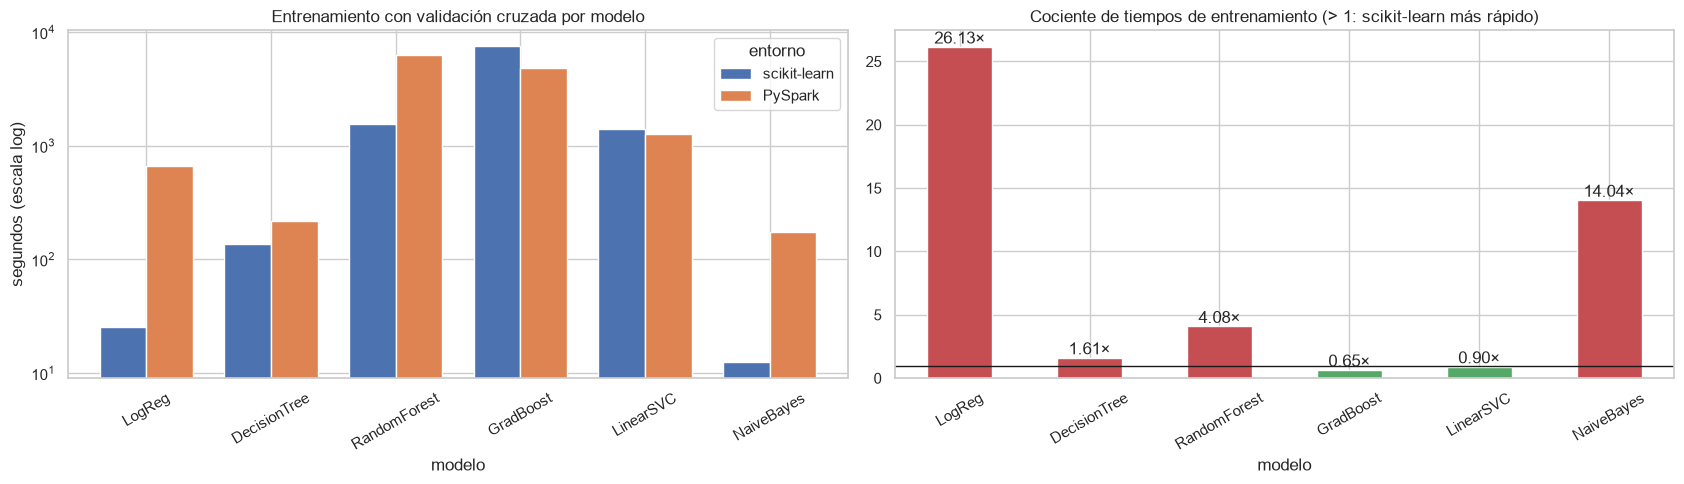

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
tr = times["entrenamiento con CV (s)"].unstack(0)[ENVS].loc[U.MODELS]
tr.plot.bar(ax=axes[0], color=["#4C72B0", "#DD8452"], logy=True, width=0.75)
axes[0].set_ylabel("segundos (escala log)")
axes[0].set_title("Entrenamiento con validación cruzada por modelo")
axes[0].tick_params(axis="x", rotation=30)
ratio = (tr["PySpark"] / tr["scikit-learn"]).rename("PySpark / scikit-learn")
ratio.plot.bar(ax=axes[1], color=np.where(ratio > 1, "#C44E52", "#55A868"))
axes[1].axhline(1, c="k", lw=1)
axes[1].set_title("Cociente de tiempos de entrenamiento (> 1: scikit-learn más rápido)")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(ratio):
    axes[1].text(i, v, f"{v:.2f}×", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 7.4 Resultados de las pruebas estadísticas

In [7]:
b = pd.DataFrame(stats_res["between"])
between = pd.DataFrame({
    "modelo": [m for m in U.MODELS],
    "AUC scikit-learn": b["auc_1"], "AUC PySpark": b["auc_2"],
    "ΔAUC (sk − spark) [IC 95 %]": [f"{d:+.4f} [{l:+.4f}, {h:+.4f}]" for d, l, h in b[["delta_auc", "delta_lo", "delta_hi"]].to_numpy()],
    "p Holm": b["p Holm"].map("{:.1e}".format),
    "significativa": b["significativa"].map({True: "sí", False: "no"}),
    "relevante (≥ 0,005)": b["relevante"].map({True: "sí", False: "no"}),
}).set_index("modelo")
print("DeLong entre entornos (familia de 6 comparaciones, Holm):")
between.style.format({"AUC scikit-learn": "{:.4f}", "AUC PySpark": "{:.4f}"})

DeLong entre entornos (familia de 6 comparaciones, Holm):


,AUC scikit-learn,AUC PySpark,ΔAUC (sk − spark) [IC 95 %],p Holm,significativa,"relevante (≥ 0,005)"
modelo,,,,,,
LogReg,0.7135,0.7135,"-0.0000 [-0.0001, +0.0000]",3.3e-01,no,no
DecisionTree,0.7029,0.7002,"+0.0027 [+0.0017, +0.0037]",3.3e-07,sí,no
RandomForest,0.7151,0.7137,"+0.0014 [+0.0010, +0.0017]",1.8e-11,sí,no
GradBoost,0.7198,0.7195,"+0.0003 [-0.0001, +0.0007]",3.3e-01,no,no
LinearSVC,0.4611,0.6300,"-0.1688 [-0.1731, -0.1645]",0.0e+00,sí,sí
NaiveBayes,0.6390,0.6395,"-0.0005 [-0.0005, -0.0004]",1.2e-32,sí,no


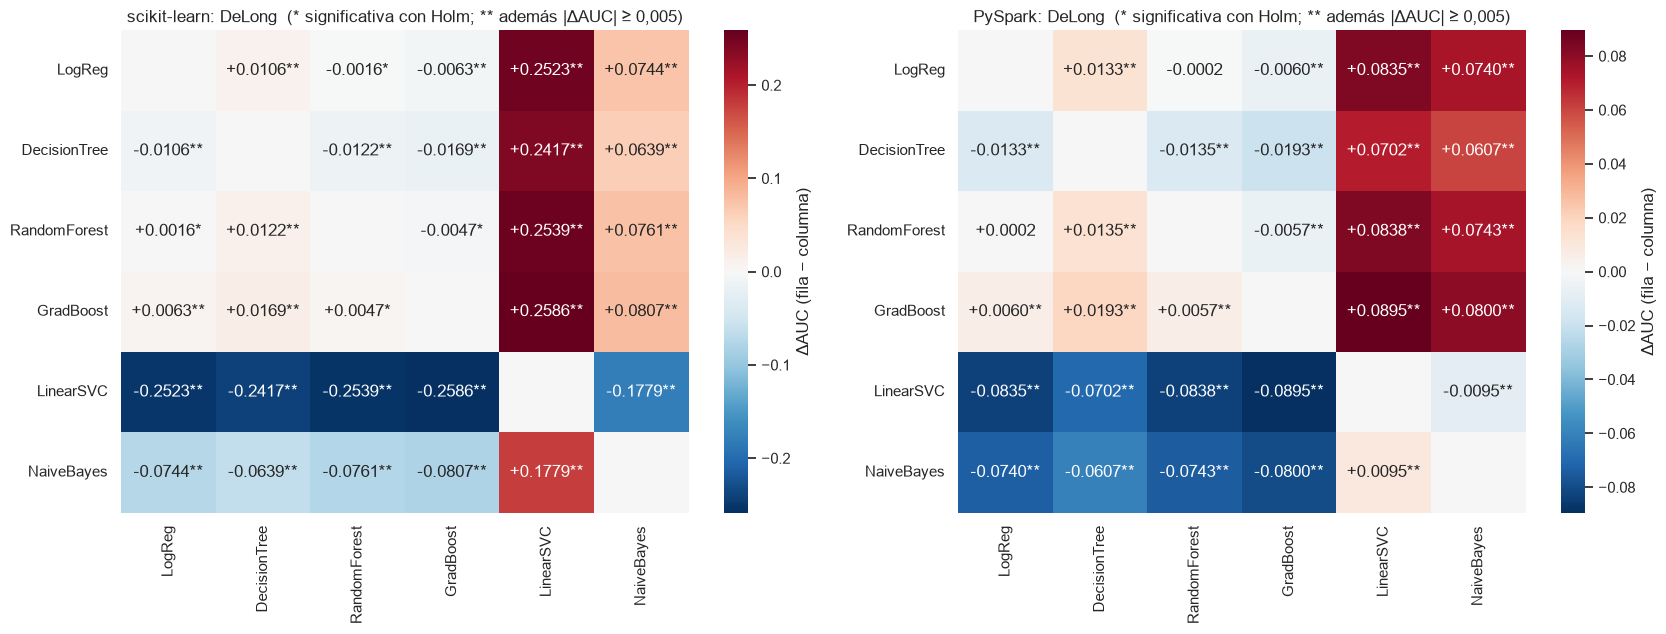

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
for ax, env in zip(axes, ENVS):
    df = pd.DataFrame(stats_res["within"][env])
    d = pd.DataFrame(0.0, index=U.MODELS, columns=U.MODELS)
    annot = pd.DataFrame("", index=U.MODELS, columns=U.MODELS)
    for _, r in df.iterrows():
        a, c = r["modelo 1"].split(" (")[0], r["modelo 2"].split(" (")[0]
        d.loc[a, c], d.loc[c, a] = r["delta_auc"], -r["delta_auc"]
        star = "" if r["p Holm"] >= 0.05 else ("*" if abs(r["delta_auc"]) < stats_res["margin"] else "**")
        annot.loc[a, c] = f"{r['delta_auc']:+.4f}{star}"
        annot.loc[c, a] = f"{-r['delta_auc']:+.4f}{star}"
    lim = np.abs(d.to_numpy()).max()
    sns.heatmap(d, annot=annot, fmt="", cmap="RdBu_r", center=0, vmin=-lim, vmax=lim, ax=ax,
                cbar_kws={"label": "ΔAUC (fila − columna)"})
    ax.set_title(f"{env}: DeLong  (* significativa con Holm; ** además |ΔAUC| ≥ 0,005)")
plt.tight_layout()
plt.show()

In [9]:
comp = pd.DataFrame(stats_res["complementary"])
yn = lambda v: "sí" if v else "no"
pd.DataFrame({
    "familia": comp["familia"], "comparación": comp["modelo 1"] + " vs " + comp["modelo 2"],
    "ΔAUC": comp["DeLong ΔAUC"].round(4),
    "DeLong": [yn(p < 0.05) for p in comp["DeLong p Holm"]],
    "McNemar": [yn(p < 0.05) for p in comp["McNemar p Holm"]],
    "bootstrap ΔAUC": [yn(p < 0.05) for p in comp["boot auc p Holm"]],
    "bootstrap ΔAUC-PR": [yn(p < 0.05) for p in comp["boot pr_auc p Holm"]],
    "bootstrap ΔF1": [yn(p < 0.05) for p in comp["boot f1 p Holm"]],
}).set_index(["familia", "comparación"])

ΔAUC DeLong McNemar bootstrap ΔAUC bootstrap ΔAUC-PR bootstrap ΔF1
familia                      comparación                                                                                                             
(i) entre entornos           LogReg (scikit-learn) vs LogReg (PySpark)          -0.0000     no      no             no                no            no
                             DecisionTree (scikit-learn) vs DecisionTree (Py...  0.0027     sí      sí             sí                sí            no
                             RandomForest (scikit-learn) vs RandomForest (Py...  0.0014     sí      sí             sí                sí            sí
                             GradBoost (scikit-learn) vs GradBoost (PySpark)     0.0003     no      no             no                sí            no
                             LinearSVC (scikit-learn) vs LinearSVC (PySpark)    -0.1688     sí      sí             sí                sí            sí
                             NaiveBayes (scikit-learn) vs NaiveBayes (PySpark)  -0.0005     sí      sí             sí                no            sí
(ii) dos mejores por entorno GradBoost (scikit-learn) vs RandomForest (sciki...  0.0047     sí      sí             sí                sí            sí
                             GradBoost (PySpark) vs RandomForest (PySpark)       0.0057     sí      sí             sí                sí            sí

## 7.5 Experimento de escalabilidad: ¿a partir de qué volumen gana PySpark?

La reflexión pregunta a partir de qué volumen de datos PySpark comienza a superar a scikit-learn. Para responder con mediciones y no con suposiciones, se mide **un único ajuste** (sin validación cruzada) de dos modelos representativos:

* la **regresión logística**, que hace muchas pasadas baratas sobre los datos;
* un **árbol de decisión** de profundidad 10, que hace pocas pasadas caras.

Cada modelo se ajusta sobre el conjunto de entrenamiento completo **replicado 1, 2 y 4 veces** (1,08 M, 2,15 M y 4,30 M de filas), con los mejores hiperparámetros de cada entorno. La réplica solo sirve para emular volúmenes mayores y medir tiempos: no aporta información nueva y no se usa para evaluar desempeño. En ningún caso se reduce el dataset.

Ambos entornos corren en el mismo equipo:

* scikit-learn usa un proceso, con L-BFGS en la regresión logística y un solo hilo en el árbol;
* Spark usa `local[*]`, con 12 particiones y caché.

In [10]:
import time
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.tree import DecisionTreeClassifier as SkDT

REPS = [1, 2, 4]
data = U.sk_train_test()
X1, y1 = data["X_train"], data["y_train"]
del data
C_best = res["scikit-learn"]["LogReg"]["best_params"]["C"]
scal = []
for k in REPS:
    Xk, yk = (np.concatenate([X1] * k), np.concatenate([y1] * k)) if k > 1 else (X1, y1)
    t0 = time.time(); SkLR(C=C_best, max_iter=1000).fit(Xk, yk); t_lr = time.time() - t0
    t0 = time.time(); SkDT(max_depth=10, random_state=U.SEED).fit(Xk, yk); t_dt = time.time() - t0
    scal.append({"filas": len(yk), "entorno": "scikit-learn", "LogReg (s)": t_lr, "DecisionTree (s)": t_dt})
    del Xk, yk
del X1, y1

In [11]:
from pyspark import StorageLevel
from pyspark.ml.classification import DecisionTreeClassifier as SpDT, LogisticRegression as SpLR

spark = U.spark_session()
sres = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)
base = sres["train"]
reg_best = res["PySpark"]["LogReg"]["best_params"]["regParam"]
for k in REPS:
    df = base
    for _ in range(k - 1):
        df = df.union(base)
    df = df.coalesce(U.SPARK_MODEL_PARTITIONS).persist(StorageLevel.MEMORY_AND_DISK)
    n = df.count()
    t0 = time.time()
    SpLR(featuresCol="features", labelCol=U.TARGET, regParam=reg_best, elasticNetParam=0.0, standardization=False,
         maxIter=100).fit(df)
    t_lr = time.time() - t0
    t0 = time.time()
    SpDT(featuresCol="features", labelCol=U.TARGET, maxDepth=10, maxBins=32, seed=U.SEED, cacheNodeIds=True).fit(df)
    t_dt = time.time() - t0
    scal.append({"filas": n, "entorno": "PySpark", "LogReg (s)": t_lr, "DecisionTree (s)": t_dt})
    df.unpersist()
U.spark_shutdown(spark)

scal_df = pd.DataFrame(scal)
scal_df.pivot(index="filas", columns="entorno").round(1)

LogReg (s)              DecisionTree (s)             
entorno    PySpark scikit-learn          PySpark scikit-learn
filas                                                        
1076248       17.0          4.9             13.4         18.7
2152496       20.8          5.6             16.3         37.0
4304992       29.3         10.6             27.9         82.0

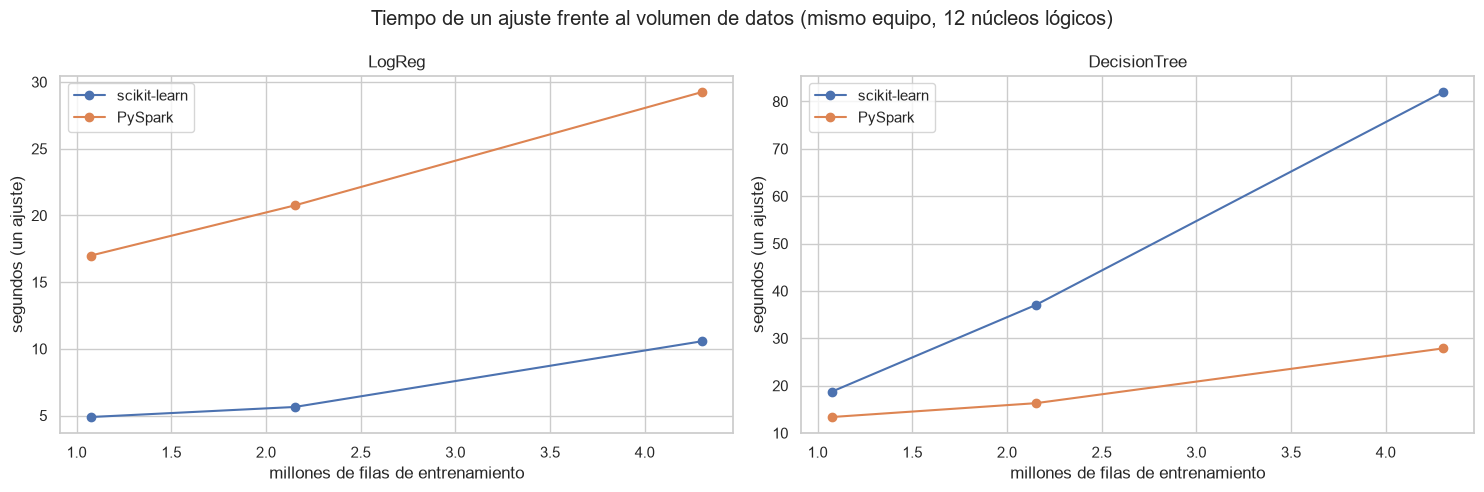

,s/millón de filas scikit-learn,s/millón de filas PySpark,costo fijo PySpark (s),cruce estimado (millones de filas)
LogReg,1.84,3.82,12.74,inf
DecisionTree,19.78,4.62,7.59,0.75


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cross = {}
for ax, m in zip(axes, ["LogReg (s)", "DecisionTree (s)"]):
    fits = {}
    for env, col in zip(ENVS, ["#4C72B0", "#DD8452"]):
        d = scal_df[scal_df["entorno"] == env]
        ax.plot(d["filas"] / 1e6, d[m], "o-", color=col, label=env)
        fits[env] = np.polyfit(d["filas"], d[m], 1)      # t = pendiente · n + costo fijo
    (b_sk, a_sk), (b_sp, a_sp) = fits["scikit-learn"], fits["PySpark"]
    n_cross = (a_sp - a_sk) / (b_sk - b_sp) if b_sk > b_sp else np.inf
    cross[m.replace(" (s)", "")] = {"s/millón de filas scikit-learn": b_sk * 1e6, "s/millón de filas PySpark": b_sp * 1e6,
                                    "costo fijo PySpark (s)": a_sp, "cruce estimado (millones de filas)": n_cross / 1e6}
    ax.set_xlabel("millones de filas de entrenamiento")
    ax.set_ylabel("segundos (un ajuste)")
    ax.set_title(m.replace(" (s)", ""))
    ax.legend()
plt.suptitle("Tiempo de un ajuste frente al volumen de datos (mismo equipo, 12 núcleos lógicos)")
plt.tight_layout()
plt.show()
pd.DataFrame(cross).T.round(2)

El experimento muestra que no existe un único volumen a partir del cual PySpark supere a scikit-learn: la respuesta depende del algoritmo. En el árbol de decisión, un ajuste único con Spark ya es más rápido con el conjunto de entrenamiento original (13,4 frente a 18,7 segundos). El cruce estimado se sitúa en torno a 0,75 millones de filas, y con 4,3 millones la ventaja de Spark es de tres veces (28 frente a 82 segundos). `DecisionTreeClassifier` de scikit-learn construye el árbol en un solo hilo y su costo crece linealmente con el volumen (19,8 s por millón de filas), mientras que Spark reparte el cálculo de histogramas entre los doce núcleos (4,6 s por millón de filas más un costo fijo de unos 8 segundos). En la regresión logística ocurre lo contrario: scikit-learn es más rápido en los tres tamaños y además escala mejor (1,8 frente a 3,8 s por millón de filas), porque L-BFGS opera sobre una matriz densa en memoria con operaciones vectorizadas y multihilo. Spark, en cambio, paga en cada iteración la agregación distribuida del gradiente. En este caso las rectas no se cruzan, de modo que en un único equipo Spark no alcanzaría a scikit-learn a ningún volumen.

Estas mediciones corresponden a un solo ajuste. En la búsqueda completa de hiperparámetros, `GridSearchCV` ajusta en paralelo hasta doce combinaciones y pliegues, mientras que `CrossValidator` las ajusta secuencialmente (con `parallelism=1` por defecto) y materializa en caché cada pliegue. Por eso el árbol, más rápido en Spark en un ajuste aislado, resultó más lento en la validación cruzada (219 frente a 136 segundos). El límite práctico de scikit-learn en este equipo no es el tiempo sino la memoria: la matriz de entrenamiento ocupa unos 364 bytes por fila en `float32`, y con `n_jobs=-1` cada proceso copia su pliegue, de modo que la validación cruzada paralela agotaría los 16 GB de RAM hacia los tres o cuatro millones de filas. Por encima de ese volumen, o en un clúster con varios nodos, Spark pasa a ser la opción viable y no solo la más rápida.

## 7.6 Modelo ganador

El modelo ganador es **gradient boosting**, que ocupa el primer lugar en ambos entornos con los mismos hiperparámetros: 100 iteraciones o árboles, profundidad 5 y tasa de aprendizaje 0,1. En el conjunto de prueba alcanza un AUC de 0,7198 en scikit-learn y de 0,7195 en PySpark, una diferencia no significativa ($p_{Holm} = 0{,}33$), con un AUC-PR de 0,389 y un F1 de 0,40. Su ventaja sobre la regresión logística (0,006 de AUC) es significativa y supera el margen de relevancia en ambos entornos. Frente al bosque aleatorio, es relevante en PySpark (0,0057) y se queda ligeramente por debajo del margen en scikit-learn (0,0047). Además, gradient boosting presenta la menor brecha entre entrenamiento y prueba de los modelos no lineales (0,004), lo que indica una buena capacidad de generalización.

Conviene dimensionar el resultado. Un AUC de 0,72, equivalente a un coeficiente de Gini de 0,44, es un desempeño moderado, típico de los modelos de originación que solo disponen de la información de la solicitud. El análisis LIME del capítulo 6 muestra que parte del error es irreducible con esas variables, y que los modelos se apoyan en buena medida en la propia tasa de interés asignada por la plataforma. Con el umbral fijado en entrenamiento, el modelo identifica el 40 % de los defaults con una precisión del 40 %, el doble de la tasa base. Desde una perspectiva práctica, la regresión logística ofrece una alternativa atractiva: pierde solo 0,006 de AUC, se entrena en segundos, sus coeficientes son directamente interpretables y es la solución más estable entre entornos. En cuanto a la implementación del ganador, los dos entornos son estadísticamente equivalentes en capacidad de ordenamiento, y la elección debe basarse en el costo. En este equipo, el GBT de Spark se entrenó en 81 minutos frente a 125 de `GradientBoostingClassifier`, aunque `HistGradientBoostingClassifier` de scikit-learn alcanzó un desempeño similar en una fracción de ese tiempo (sección 3.7).

## 7.7 Reflexión crítica

**¿Qué entorno fue más rápido y por qué?** scikit-learn completó el flujo en 178 minutos y PySpark en 229, es decir, 1,29 veces más. scikit-learn fue más rápido en el preprocesamiento (40 frente a 158 segundos), en la predicción y en cuatro de los seis modelos. La regresión logística fue 26 veces más rápida y Naive Bayes 14 veces. PySpark solo aventajó a scikit-learn en gradient boosting (81 frente a 125 minutos) y, marginalmente, en LinearSVC. La expectativa del enunciado de que PySpark superara en velocidad a scikit-learn no se cumplió en estas condiciones, y la razón es estructural. Con 1,35 millones de filas, la matriz de entrenamiento ocupa 392 MB y cabe holgadamente en la memoria de un único equipo. En ese régimen, Spark no aporta capacidad adicional y sí añade costos fijos en cada pasada sobre los datos: planificación de tareas, serialización entre Python y la JVM, agregaciones en árbol y materialización de pliegues. Estos costos dominan en los algoritmos de muchas iteraciones baratas y se amortizan en los de pocas pasadas costosas, como la construcción de árboles profundos. El caché resultó indispensable (sin él, un ajuste fue catorce veces más lento). El `CrossValidator` secuencial multiplicó por diez o más el costo de un ajuste aislado. Y la configuración obligatoria, con 400 particiones pensadas para un clúster, ralentizaba entre seis y diez veces los ajustes en un equipo de doce núcleos, lo que obligó a reducir las particiones de los DataFrames de modelado a doce.

**¿Cuál fue más preciso?** En términos prácticos, ninguno. En el modelo ganador y en la regresión logística, los dos entornos son estadísticamente indistinguibles en AUC. scikit-learn obtuvo pequeñas ventajas significativas en el árbol (+0,0027) y en el bosque (+0,0014), y en el AUC-PR del boosting (+0,0013), todas muy por debajo del margen de relevancia. PySpark superó ampliamente a scikit-learn en LinearSVC (+0,169), pero por diferencias del optimizador y no por una mayor capacidad del entorno.

**¿Qué diferencias en el AUC fueron significativas tras la corrección por comparaciones múltiples, y cuáles son relevantes en la práctica?** Entre entornos, cuatro de las seis comparaciones son significativas con Holm (árbol, bosque, Naive Bayes y LinearSVC), pero solo la de LinearSVC es relevante. Dentro de cada entorno, 15 de 15 pares en scikit-learn y 14 de 15 en PySpark son significativos, y 13 y 14, respectivamente, superan además el margen de 0,005. Las diferencias relevantes separan tres niveles de desempeño: gradient boosting en la cima; el bosque y la regresión logística en un nivel intermedio, prácticamente empatados; y el árbol, Naive Bayes y LinearSVC por debajo. Con 269 mil observaciones de prueba y modelos muy correlacionados, la significancia estadística es casi automática, y es el margen de relevancia, fijado antes de ver los resultados, el que permite una lectura sustantiva.

**¿Qué diferencias de implementación explican las discrepancias?** La más importante es la formulación de LinearSVC. scikit-learn solo admite la pérdida hinge mediante el dual de liblinear, que además regulariza el intercepto y no converge con valores grandes de $C$. Spark optimiza el primal con OWL-QN sin penalizar el intercepto. Con la misma pérdida, esto produce un AUC de 0,46 frente a 0,63. En los árboles, Spark discretiza cada variable continua en 32 intervalos por cuantiles aproximados, mientras que scikit-learn evalúa todos los cortes posibles. Además, el *bootstrap* y el submuestreo de variables del bosque siguen generadores aleatorios distintos que dependen del particionado. En la regresión logística, la relación $C = 1/(\lambda n)$ es solo aproximada porque $C$ pondera la suma de las pérdidas y `regParam` su promedio, y porque en validación cruzada cada pliegue tiene $2n/3$ observaciones; aun así, la superficie de validación es tan plana que ambos entornos llegan al mismo AUC con parámetros distintos. Otros detalles menores también influyen: Spark estima la desviación estándar muestral y scikit-learn la poblacional, scikit-learn añade un término de estabilidad a las varianzas de Naive Bayes, y los pliegues de validación cruzada difieren entre entornos. Ninguna de estas diferencias altera las conclusiones sobre los modelos.

**¿Qué limitaciones tiene la prueba de DeLong en este diseño experimental y cómo la complementan McNemar y el bootstrap pareado? ¿Coinciden las conclusiones?** DeLong solo cuantifica la variabilidad debida al muestreo del conjunto de prueba, no la del entrenamiento (semillas, pliegues o *bootstrap*). Además, supone observaciones independientes y resume el desempeño en todos los umbrales, sin informar sobre el punto de operación. McNemar evalúa las decisiones en el umbral elegido, aunque pondera por igual los falsos positivos y los falsos negativos, cuyo costo en crédito es muy distinto. El bootstrap pareado prescinde de aproximaciones asintóticas y extiende la comparación al AUC-PR y al F1, más informativos para la clase minoritaria. Las conclusiones coinciden plenamente en lo esencial: DeLong, el bootstrap del AUC y McNemar concuerdan en las ocho comparaciones complementarias. Las únicas discrepancias aparecen en el AUC-PR y el F1, que capturan aspectos del desempeño que el AUC no refleja. Ninguna de las tres pruebas resuelve la limitación de no considerar la variabilidad del entrenamiento; para ello se requerirían esquemas de remuestreo del entrenamiento, como 5×2cv, cuyo costo computacional era prohibitivo aquí.

**¿A partir de qué volumen de datos PySpark comienza a superar a scikit-learn?** Según el experimento de la sección 7.5, depende del algoritmo y del esquema de entrenamiento. En un ajuste único de árbol, Spark ya es más rápido a partir de unos 0,75 millones de filas y su ventaja crece con el volumen. En la regresión logística no se observa cruce en un único equipo. Con validación cruzada, el paralelismo entre ajustes de `GridSearchCV` desplaza el cruce hacia volúmenes mayores. En consecuencia, la ventaja decisiva de Spark en un único equipo aparece cuando los datos dejan de caber en la memoria de un proceso de scikit-learn, lo que en este equipo ocurriría hacia los tres o cuatro millones de filas con validación cruzada paralela. En un clúster, Spark escala horizontalmente y su ventaja se manifiesta a volúmenes muy superiores a los de este problema.

**¿Qué aporta LIME y cuáles son sus limitaciones en entornos distribuidos?** LIME permitió verificar que los dos modelos ganadores se equivocan por las mismas razones y que se apoyan en variables con sentido económico (tasa de interés, plazo, puntaje FICO, endeudamiento), lo que aporta validez sustantiva a los modelos y ayuda a distinguir el error irreducible del error del modelo. Su limitación principal en un entorno distribuido es el costo: cada explicación exige un trabajo de Spark completo, y explicar una predicción tomó unas 500 veces más que en scikit-learn (380 frente a 0,75 segundos). A ello se suman la necesidad de disponer en memoria local de las estadísticas del entrenamiento y la dificultad para trasladar el modelo al lugar donde se ejecuta el explicador. A estas se añaden las limitaciones generales del método: perturbaciones que ignoran la correlación entre variables, dependencia de la discretización y del *kernel*, y carácter estrictamente local de las explicaciones.

**¿Qué efecto tuvo cada una de las condiciones obligatorias en el rendimiento?** El **uso del dataset completo** (1,35 millones de préstamos) hizo que el entrenamiento de gradient boosting en scikit-learn superara las dos horas. A cambio, produjo intervalos de confianza muy estrechos (±0,0024 de AUC), que hacen significativas diferencias ínfimas y obligan a interpretar con el margen de relevancia. El **caché obligatorio** fue la condición de mayor impacto positivo: sin él, cada iteración releería el CSV de 1,7 GB, con una penalización de catorce veces. El uso exclusivo de **`CrossValidator` con `ParamGridBuilder`**, sin bucles manuales, garantizó un procedimiento de selección equivalente al de `GridSearchCV`, pero con ajustes secuenciales y pliegues materializados en caché, lo que multiplicó el costo y la presión sobre la memoria. La **configuración de la sesión** tuvo efectos mixtos. Las 400 particiones de `spark.sql.shuffle.partitions` y `spark.default.parallelism` resultaron contraproducentes en un único equipo (entre seis y diez veces más lentas) y se mitigaron con un `coalesce` justificado experimentalmente. `spark.driver.memory=8g`, en un equipo de 16 GB compartido con el sistema operativo, dejó un margen estrecho, que contribuyó a los fallos por memoria documentados en el capítulo 4. `spark.executor.memory` no tiene efecto en modo local, y `spark.memory.fraction=0.8` favoreció el caché de los pliegues. La **prohibición de `.toPandas()` y `.collect()`** obligó a calcular las métricas de forma distribuida y limitó la transferencia al driver a las puntuaciones de prueba (42 segundos en total para los seis modelos), sin impacto relevante en el tiempo, aunque sí en la complejidad del código y de la interpretabilidad. Por último, la **partición común** guardada en disco fue la condición metodológica clave: sin ella, las pruebas pareadas entre entornos no habrían sido posibles.

En síntesis, en un problema de 1,35 millones de observaciones que cabe en la memoria de un solo equipo, scikit-learn y PySpark alcanzan desempeños estadísticamente equivalentes en los modelos bien especificados, y scikit-learn resulta en general más rápido. La elección del entorno debe guiarse por el volumen de los datos y la infraestructura disponible, más que por la precisión esperada. La elección del algoritmo, y en particular de su formulación y su optimizador, como muestra el caso de LinearSVC, pesa más en el resultado que la elección de la librería.